### **Day-1**

In [18]:
# Setting global seeds

import random
import numpy as np
import os
import torch

def set_seed(seed=42):
  """
  Sets seeds for reproducibility across numpy, python and Pytorch
  """
  # 1. Python's built-in random
  random.seed(seed)
  # 2. NumPy (used by Pandas and Scikit-Learn)
  np.random.seed(seed)
  # 3. Environment variable for hashing (ensures dictionary order consistency)
  os.environ['PYTHONHASHSEED'] = str(seed)
  # 4. PyTorch (even though we aren't using it yet, it's good habit)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f"Random seed set as {seed}")

SEED = 42
set_seed(SEED)


Random seed set as 42


In [ ]:
%pip install pandas numpy scikit-learn nltk wandb pandera matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.9/295.9 kB 5.9 MB/s eta 0:00:00


In [ ]:
%pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.9
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
aiosqlite                                0.21.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                                    4.12.0
anywidget                           

In [ ]:
import wandb
%wandb login --relogin

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [ ]:
import random
import numpy as np
import pandas as pd
import pandera.pandas as pa
import wandb
import tarfile
import urllib.request
import glob as glob
import tqdm as tqdm # Progress Bar
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
import joblib   
import os

In [15]:
def download_aclImdb():
  url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
  if not os.path.exists('aclImdb_v1.tar.gz'):
    urllib.request.urlretrieve(url, 'aclImdb_v1.tar.gz')
  if not os.path.exists('aclImdb'):
    print("Extracting dataset...")
    with tarfile.open('aclImdb_v1.tar.gz', 'r:gz') as tar:
      tar.extractall()

In [19]:
def load_imdb_data(data_dir='aclImdb'):
  """
  Reads the raw text files from the aclImdb folder structure:
  aclImdb/train/pos, aclImdb/train/neg
  """
  # check if data exists, if not downloading it
  if not os.path.exists(data_dir):
    download_aclImdb()

  data={}

  # Iterate over splits (train/test) and sentiments (pos/neg)
  for split in ['train', 'test']:
    data[split] = []
    for sentiment,label in [('pos',1), ('neg',0)]:
      path = os.path.join(data_dir, split, sentiment, '*.txt')
      files = glob.glob(path)

      print(f"Loading {split} - {sentiment} ({len(files)} files)...")

      for file_path in tqdm.tqdm(files, leave=False):
        with open(file_path, 'r', encoding='utf-8') as f:
          text = f.read()
          data[split].append({'text': text, 'label': label})

  # Convert to dataframes and shuffle with seed
  train_df = pd.DataFrame(data['train']).sample(frac=1,random_state=SEED).reset_index(drop=True)
  test_df = pd.DataFrame(data['test']).sample(frac=1,random_state=SEED).reset_index(drop=True)

  return train_df, test_df

# loading the data
train_df,test_df = load_imdb_data('aclImdb')
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

Loading train - pos (12500 files)...


Loading train - neg (12500 files)...


Loading test - pos (12500 files)...


Loading test - neg (12500 files)...


Train Shape: (25000, 2)
Test Shape: (25000, 2)


In [28]:
train_df.sample(5)

,text,label,clean_text
6868,The Lady From Shanghai is weird even by the st...,1,the lady from shanghai is weird even by the st...
24016,"The author of numerous novels, plays, and shor...",0,the author of numerous novels plays and short ...
9668,A woman borough a boy to this world and was al...,1,a woman borough a boy to this world and was al...
13640,Seriously. This is one of the most stupid fami...,0,seriously this is one of the most stupid famil...
14018,I am a huge John Denver fan. I have a large co...,1,i am a huge john denver fan i have a large col...


In [27]:
test_df.head(5)

,text,label,clean_text
0,Dan Dailey gives a sincere and colorful perfor...,1,dan dailey gives a sincere and colorful perfor...
1,What a self-indulgent mess! Duncan Roy's film ...,0,what a selfindulgent mess duncan roys film is ...
2,"""The Beguiled"" is a strange work among Clint E...",1,the beguiled is a strange work among clint eas...
3,"Seriously, all these Satan comes to Earth movi...",0,seriously all these satan comes to earth movie...
4,The digital effects were done on the cheap and...,0,the digital effects were done on the cheap and...


In [22]:
# Define Schema
schema = pa.DataFrameSchema({
    "text": pa.Column(str, checks=pa.Check.str_length(min_value=1)), # Text must not be empty
    "label": pa.Column(int, checks=pa.Check.isin([0, 1])) # Label must be 0 or 1
})

try:
    schema.validate(train_df)
    schema.validate(test_df)
    print("Data Validation Passed: Schema is correct.")
except pa.errors.SchemaError as e:
    print("Data Validation Failed:", e)

Data Validation Passed: Schema is correct.


In [23]:
# Data Cleaning
import re

def clean_text(text):
    # Remove HTML breaks often found in this dataset
    text = re.sub(r'<br\s*/?>', ' ', text)
    # Keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase and trim
    text = text.lower().strip()
    return text

print("Cleaning text")
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)
print("Cleaning complete.")

Cleaning text
Cleaning complete.


In [33]:
# Training with W&B
# Initialize W&B run

run = wandb.init(
    project='Week-4',
    name='baseline-training',
    tags=['baseline','aclImdb','tfidf'],
    config={
        'dataset':'aclImdb_raw',
        'max_features':5000,
        'ngram_range':(1,2),
        'C_param':1.0,
        "random_seed":SEED
    }
)
config= wandb.config

# Prepare Data
X_train = train_df['clean_text']
y_train = train_df['label']
X_test = test_df['clean_text']
y_test = test_df['label']

# Building Pipeline
# gonna pass SEED to logisticRegression
pipeline = Pipeline([
    ('tfidf',TfidfVectorizer(max_features=config.max_features, ngram_range=tuple(config.ngram_range))), # Explicitly cast to tuple here
    ('clf', LogisticRegression(random_state=config.random_seed, C=config.C_param, solver='liblinear'))
])

# Train
print("Training the Model")
pipeline.fit(X_train, y_train)

# Predict
print("Evaluating the Model")
y_pred = pipeline.predict(X_test)

# Metrics
macro_f1 = f1_score(y_test, y_pred, average='macro')
accuracy = accuracy_score(y_test, y_pred)

print(f'Macro F1 Score: {macro_f1:.4f}')
print(f'Accuracy: {accuracy:.4f}')

# Log Metrics
wandb.log({'macro_f1': macro_f1, 'accuracy': accuracy})
wandb.log({
    'confusion_matrix': wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_test.values,
        preds=y_pred,
        class_names=['Negative','Positive']
    )
})


Training the Model
Evaluating the Model
Macro F1 Score: 0.8884
Accuracy: 0.8884


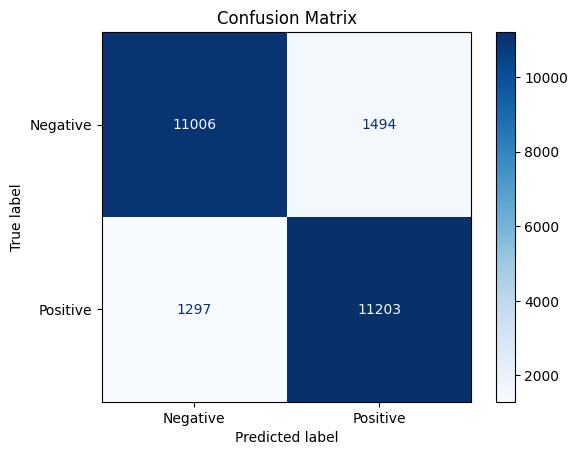

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [35]:
# Failure Analysis and Artifacts
# 1. Identifying errors

results = test_df.copy()
results['pred'] = y_pred

In [36]:
results.sample(5)

,text,label,clean_text,pred
17423,This is one of those films with a great potent...,0,this is one of those films with a great potent...,0
14441,"I'm sorry, but ""Star Wars Episode 1"" did not d...",1,im sorry but star wars episode did not do any...,0
20743,Like in a circle the movie leads back to its p...,1,like in a circle the movie leads back to its p...,1
3253,Leonard Maltin gave this film a dreaded BOMB r...,1,leonard maltin gave this film a dreaded bomb r...,1
7503,"This story of Ted Brice, an American pilot who...",0,this story of ted brice an american pilot who ...,0


In [37]:
# False Positives (Actual Neg, Pred Pos)
fp = results[(results['label']==0) & (results['pred']==1)]
fp.head()

,text,label,clean_text,pred
7,"The film is somewhat entertaining, but the gre...",0,the film is somewhat entertaining but the grea...,1
25,SPOILERS!<br /><br />I gave this film 2 out of...,0,spoilers i gave this film out of for scene...,1
56,Michael Dudikoff stars as Joe Armstrong a mart...,0,michael dudikoff stars as joe armstrong a mart...,1
71,The 70s were without a doubt the golden age of...,0,the s were without a doubt the golden age of m...,1
74,It's unlikely that anyone except those who ado...,0,its unlikely that anyone except those who ador...,1


In [38]:
# False Negative (Actual Pos, Pred Neg)
fn = results[(results['label']==1) & (results['pred']==0)]
fn.head()

,text,label,clean_text,pred
33,"OK, I am a sucker. I loved it. I had no expect...",1,ok i am a sucker i loved it i had no expectati...,0
34,What a show! Lorenzo Lamas once again proves h...,1,what a show lorenzo lamas once again proves hi...,0
73,Not every line in a comedy is funny. This movi...,1,not every line in a comedy is funny this movie...,0
97,I saw the movie yesterday and was shocked by i...,1,i saw the movie yesterday and was shocked by i...,0
111,if you are dating a girl that is into wicca!<b...,1,if you are dating a girl that is into wicca m...,0


In [39]:
print(f"Found {len(fp)} false positives and {len(fn)} false negatives.")

Found 1494 false positives and 1297 false negatives.


In [40]:
# Saving files locally
fp.head(50).to_csv('false_positives.csv', index=False)
fn.head(50).to_csv('false_negatives.csv', index=False)
joblib.dump(pipeline, "baseline_model.pkl")

['baseline_model.pkl']

In [42]:
# Upload to W&B

artifact = wandb.Artifact("baseline_results_raw_data", type="model-results")
artifact.add_file("false_positives.csv")
artifact.add_file("false_negatives.csv")
artifact.add_file("baseline_model.pkl")

run.log_artifact(artifact)

print("Artifacts Uploaded")
wandb.finish()

Artifacts Uploaded


accuracy,▁
macro_f1,▁
accuracy,0.88836
macro_f1,0.88835
